# Battery Optimisation: Exploring Policies and RL Agents

This notebook walks through a progression from **rule-based baselines** to a **Q-learning RL agent**,
all applied to the same problem: deciding when to charge and discharge a home battery to minimise
electricity costs.

**Structure**
1. Load data and define a shared evaluation framework
2. Baseline: no battery (upper bound on cost)
3. Rule-based policy 1: self-consumption (charge on solar surplus)
4. Rule-based policy 2: off-peak charging (use tariff signal)
5. Introduction to RL concepts
6. Q-learning agent — implementation and training
7. Results comparison

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

CONFIG_PATH = Path("../configs/default.yaml")

with CONFIG_PATH.open() as f:
    config = yaml.safe_load(f)

DATA_DIR = Path("..") / config["data"]["combined_dir"]

BATTERY_CAPACITY_KWH  = config["battery"]["capacity_kwh"]
CHARGE_EFFICIENCY     = config["battery"]["charge_efficiency"]
DISCHARGE_EFFICIENCY  = config["battery"]["discharge_efficiency"]
MAX_CHARGE_RATE_KW    = config["battery"]["max_charge_rate_kw"]
MAX_DISCHARGE_RATE_KW = config["battery"]["max_discharge_rate_kw"]


In [2]:
def make_episodes(
    costs_df: pd.DataFrame,
    train_ids: list[int],
    val_ids: list[int],
) -> tuple[dict, dict]:
    train_episodes = {}
    val_episodes   = {}

    for customer_id in train_ids:
        train_episodes[customer_id] = costs_df[
            costs_df["customer_id"] == customer_id
        ].reset_index(drop=True)

    for customer_id in val_ids:
        val_episodes[customer_id] = costs_df[
            costs_df["customer_id"] == customer_id
        ].reset_index(drop=True)

    return train_episodes, val_episodes


In [3]:
augrid_df = pd.read_csv(DATA_DIR / "augrid_costs.csv", parse_dates=["timestamp"])

# Filter to first year for manageable episode length (744 h → fast Q-learning)
augrid_df = augrid_df[
    (augrid_df["timestamp"] >= "2010-07-01") &
    (augrid_df["timestamp"] <  "2011-07-01")
].copy()

train_episodes_dict, val_episodes_dict = make_episodes(
    augrid_df,
    config["data_splits"]["train_ids"],
    config["data_splits"]["val_ids"],
)

# Small sample for the baseline/Q-learning demo in this notebook
SAMPLE_CUSTOMERS = list(train_episodes_dict.keys())[:3]
CUSTOMERS = {cid: train_episodes_dict[cid] for cid in SAMPLE_CUSTOMERS}

for cid, cdf in CUSTOMERS.items():
    print(f"Customer {cid}: {len(cdf)} hours, "
          f"{cdf['timestamp'].iloc[0]} → {cdf['timestamp'].iloc[-1]}, "
          f"solar cap {cdf['generator_capacity_kwp'].iloc[0]:.2f} kWp, "
          f"postcode {cdf['postcode'].iloc[0]}")


Customer 63: 8760 hours, 2010-07-01 00:00:00 → 2011-06-30 23:00:00, solar cap 1.00 kWp, postcode 2085
Customer 48: 8760 hours, 2010-07-01 00:00:00 → 2011-06-30 23:00:00, solar cap 2.96 kWp, postcode 2010
Customer 191: 8760 hours, 2010-07-01 00:00:00 → 2011-06-30 23:00:00, solar cap 3.24 kWp, postcode 2227


## 1. Evaluation Framework

Before testing any policy we need a consistent way to measure performance.
All policies will be evaluated by the same function, which returns a dict of metrics.

A **policy** is a function that receives the current state and returns one of three actions:

| Action | Meaning |
|--------|----------------------------------------------------------|
| `1`    | Charge battery (from solar surplus or grid)             |
| `0`    | Idle — do nothing                                        |
| `-1`   | Discharge battery to cover grid demand                   |

The `state` dict passed to each policy contains everything visible to the controller at that hour.

In [4]:



print("Evaluation helpers defined.")


Evaluation helpers defined.


## 2. Baseline: No Battery

This policy ignores the battery entirely — all demand is met from the grid.
It sets our upper-bound cost: any policy that uses the battery should beat this.

In [5]:
def no_battery_policy(state: dict) -> int:
    return 0


no_battery_results = simulate_all(no_battery_policy, "No battery", val_episodes_dict)
calculate_total_savings(no_battery_results)

Aggregate Results across all customers:
Total savings vs baseline: A$0.00 (0.0%)
Average saving per customer: A$0.00 (0.0%)


## 3. Rule-Based Policy 1: Self-Consumption

The simplest useful policy: **charge when you have solar surplus, discharge when you have unmet demand**.
It uses the battery as a solar buffer — storing excess midday generation and using it in the evening.

This policy only looks at instantaneous solar vs consumption. It ignores the tariff entirely.

In [6]:
def self_consumption_policy(state: dict) -> int:
    if state["surplus"] > 0:
        return 1
    if state["demand"] > 0:
        return -1
    return 0


self_cons_results = simulate_all(self_consumption_policy, "Self-consumption", val_episodes_dict)
calculate_total_savings(self_cons_results)

Aggregate Results across all customers:
Total savings vs baseline: A$8086.47 (57.5%)
Average saving per customer: A$231.04 (15.8%)


## 4. Rule-Based Policy 2: Off-Peak Tariff Charging

This policy uses the **tariff signal** rather than solar data:
- **Peak hours** (rate ≥ £0.40/kWh): discharge to avoid buying expensive electricity
- **Off-peak hours** (rate ≤ £0.25/kWh): charge from grid to fill the battery cheaply

The key insight over self-consumption: it's sometimes worth buying cheap electricity to avoid
paying for expensive electricity later — even if there's no solar surplus.

This is the first policy that makes a **forward-looking** decision based on price signals.

In [8]:
# AU tariff: off-peak 0.20, shoulder 0.28, peak 0.45
PEAK_RATE_THRESHOLD     = 0.40   # discharge above this (captures 0.45 peak)
OFF_PEAK_RATE_THRESHOLD = 0.22   # charge below this  (captures 0.20 off-peak)


def off_peak_charging_policy(state: dict) -> int:
    rate = state["rate"]
    soc  = state["battery_soc"]
    cap  = state["battery_capacity"]
    if rate >= PEAK_RATE_THRESHOLD and soc > 0:
        return -1
    if rate <= OFF_PEAK_RATE_THRESHOLD and soc < cap:
        return 1
    return 0


off_peak_results = simulate_all(off_peak_charging_policy, "Off-peak charging", val_episodes_dict)


## 5. Introduction to Reinforcement Learning

The two policies above required a human to hand-code the rules. RL lets an **agent** discover
good rules on its own by **trial and error**.

### The core framework: Markov Decision Processes (MDPs)

An MDP has four components:

```
     ┌─────────────────────────────────────────────┐
     │                 Environment                 │
     │  (battery, grid, solar, tariff schedule)    │
     └──────────────┬──────────────────────────────┘
                    │  state s_t, reward r_t
                    ▼
             ┌─────────────┐
             │    Agent    │  ──── action a_t ────▶ Environment
             └─────────────┘
```

| Concept     | In our problem                                                |
|-------------|---------------------------------------------------------------|
| **State** s | Battery SoC, hour of day, current tariff, solar surplus       |
| **Action** a | Charge (1), idle (0), discharge (-1)                         |
| **Reward** r | Negative cost at this timestep: `-grid_demand × rate`        |
| **Episode** | One month of hourly data (744 steps)                         |

The agent's goal: learn a **policy** π(s) → a that **maximises total reward** (minimises total cost).

### Q-Learning

Q-learning learns a function **Q(s, a)** — the expected total future reward of taking action `a`
in state `s` and acting optimally afterwards. Once Q is learned, the policy is just:

```
π(s) = argmax_a Q(s, a)    # pick the action with highest expected return
```

**The Q-learning update rule** (run after every step):

```
Q(s, a) ← Q(s, a) + α × [r + γ × max_a' Q(s', a')  −  Q(s, a)]
                          └────────────────────────┘
                             TD target: reward now + best future value
```

| Symbol | Name            | Meaning                                                     |
|--------|-----------------|-------------------------------------------------------------|
| α      | Learning rate   | How fast Q updates — too high = unstable, too low = slow   |
| γ      | Discount factor | How much future rewards matter (0=myopic, 1=far-sighted)   |
| TD     | Temporal diff.  | The error between current Q estimate and the new evidence  |

### Exploration vs exploitation

The agent must balance:
- **Exploiting** what it already knows (take the action with best known Q)
- **Exploring** to discover better actions it hasn't tried yet

We use **ε-greedy**: with probability ε take a random action, otherwise take the best known action.
ε starts high (lots of exploration) and decays to a small value (mostly exploitation) during training.

## 6. Q-Learning Agent

### State discretisation

Q-learning (tabular) needs a **finite, discrete** state space. Our state variables are continuous,
so we bin them:

| Variable         | Bins | Rationale                                          |
|------------------|------|----------------------------------------------------|
| Battery SoC      | 5    | 20% increments (0–20%, 20–40%, …, 80–100%)        |
| Tariff rate      | 2    | Low (≤£0.25) vs high (>£0.25)                     |
| Hour of day      | 6    | 4-hour blocks (overnight, morning, …, late evening)|
| Has solar surplus| 2    | Binary — is there excess solar right now?          |

Total state space: 5 × 2 × 6 × 2 = **120 states** (tiny — perfect for a Q-table).

In [6]:
def discretise_state(state: dict, battery_capacity: float = BATTERY_CAPACITY_KWH) -> tuple:
    """Map continuous state variables to a discrete (hashable) tuple for the Q-table."""
    soc_bin  = min(int(state["battery_soc"] / battery_capacity * 5), 4)  # 0–4
    # AU tariff: 0.20 off-peak | 0.28 shoulder | 0.45 peak → 3 bins
    if state["rate"] <= 0.22:
        rate_bin = 0   # off-peak
    elif state["rate"] <= 0.35:
        rate_bin = 1   # shoulder
    else:
        rate_bin = 2   # peak
    hour_bin  = state["hour"] // 4                   # 0–5  (4-hour blocks)
    solar_bin = 1 if state["surplus"] > 0.05 else 0  # has meaningful surplus
    return (soc_bin, rate_bin, hour_bin, solar_bin)


# Sanity check
example_states = [
    {"battery_soc": 0.0, "rate": 0.20, "hour": 2,  "surplus": 0.0},
    {"battery_soc": 5.0, "rate": 0.45, "hour": 17, "surplus": 0.0},
    {"battery_soc": 9.5, "rate": 0.28, "hour": 12, "surplus": 1.2},
]
for s in example_states:
    print(f"SoC={s['battery_soc']:.1f} rate={s['rate']} hour={s['hour']:02d} surplus={s['surplus']:.1f}  →  {discretise_state(s)}")


SoC=0.0 rate=0.2 hour=02 surplus=0.0  →  (0, 0, 0, 0)
SoC=5.0 rate=0.45 hour=17 surplus=0.0  →  (2, 2, 4, 0)
SoC=9.5 rate=0.28 hour=12 surplus=1.2  →  (4, 1, 3, 1)


In [14]:
class QLearningAgent:
    """Tabular Q-learning agent for the battery optimisation task.

    Actions are encoded as indices for the Q-table:
        0 → discharge (-1)
        1 → idle (0)
        2 → charge (+1)
    """

    ACTION_MAP = {0: -1, 1: 0, 2: 1}   # table index → environment action
    N_ACTIONS = 3

    def __init__(
        self,
        alpha: float = 0.1,
        gamma: float = 0.95,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.05,
        epsilon_decay_episodes: int = 80,
    ):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = (epsilon_start - epsilon_end) / epsilon_decay_episodes
        self.q_table: dict[tuple, np.ndarray] = {}  # state → Q-values for 3 actions

    def _q(self, state: tuple) -> np.ndarray:
        """Return Q-values for `state`, initialising to zeros if unseen."""
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.N_ACTIONS)
        return self.q_table[state]

    def select_action(self, state: tuple, training: bool = True) -> int:
        """ε-greedy action selection. Returns an environment action (-1 / 0 / 1)."""
        if training and np.random.random() < self.epsilon:
            action_idx = np.random.randint(self.N_ACTIONS)
        else:
            action_idx = int(np.argmax(self._q(state)))
        return self.ACTION_MAP[action_idx]

    def update(self, state: tuple, action: int, reward: float, next_state: tuple) -> None:
        """Apply the Q-learning update rule for one (s, a, r, s') transition."""
        # Convert environment action back to table index
        action_idx = {v: k for k, v in self.ACTION_MAP.items()}[action]

        current_q = self._q(state)[action_idx]
        td_target = reward + self.gamma * np.max(self._q(next_state))
        td_error = td_target - current_q

        self.q_table[state][action_idx] += self.alpha * td_error

    def decay_epsilon(self) -> None:
        """Call once per episode to reduce exploration rate."""
        self.epsilon = max(self.epsilon_end, self.epsilon - self.epsilon_decay)

    def greedy_policy(self):
        """Return a policy function (for use with simulate()) that acts greedily."""
        def policy(state: dict) -> int:
            s = discretise_state(state)
            return self.select_action(s, training=False)
        return policy

## 7. Training

Each **episode** is one full pass through the month of data.
After each step, we update Q using the reward (`-cost_this_step`).

Note: Q-learning learns from a **single sequence of data** here (no environment model or
random resets). This is intentional — we're exploring the algorithm before building the
Gymnasium environment in Phase 2, which will support proper episode sampling.

In [ ]:
def train_q_agent(
    df_dict pd.DataFrame,
    agent: QLearningAgent,
    n_episodes: int = None,
) -> list[float]:
    """Train `agent` by running `n_episodes` passes over `df`.

    Returns a list of total episode costs (one per episode).
    """

    if n_episodes == None:
        n_episodes = len(df_dict.items())

    
    episode_costs = []
    

    for df in df_dict.values():
        battery_soc = 0.0
        total_cost  = 0.0

        for i, row in enumerate(rows):
            consumption = row["total_consumption"]
            solar       = row["gg_kwh"]
            rate        = row["import_tariff"]
            hour        = row["timestamp"].hour

            surplus = max(solar - consumption, 0.0)
            demand  = max(consumption - solar, 0.0)

            state_dict = {
                "consumption": consumption, "solar": solar,
                "surplus": surplus,         "demand": demand,
                "rate": rate,               "hour": hour,
                "battery_soc": battery_soc, "battery_capacity": BATTERY_CAPACITY_KWH,
            }
            state  = discretise_state(state_dict)
            action = agent.select_action(state, training=True)

            if action == 1:
                charge_rate  = min(surplus, MAX_CHARGE_RATE_KW, BATTERY_CAPACITY_KWH - battery_soc)
                battery_soc += charge_rate * CHARGE_EFFICIENCY
                grid_demand  = demand
            elif action == -1:
                discharge_rate = min(demand, MAX_DISCHARGE_RATE_KW, battery_soc)
                battery_soc   -= discharge_rate
                grid_demand    = max(demand - discharge_rate * DISCHARGE_EFFICIENCY, 0.0)
            else:
                grid_demand = demand

            cost    = grid_demand * rate
            reward  = -cost
            total_cost += cost

            next_row        = rows[i + 1] if i + 1 < len(rows) else row
            next_state_dict = {
                "surplus":          max(next_row["gg_kwh"] - next_row["total_consumption"], 0.0),
                "demand":           max(next_row["total_consumption"] - next_row["gg_kwh"], 0.0),
                "rate":             next_row["import_tariff"],
                "hour":             next_row["timestamp"].hour,
                "battery_soc":      battery_soc,
                "battery_capacity": BATTERY_CAPACITY_KWH,
            }
            next_state = discretise_state(next_state_dict)
            agent.update(state, action, reward, next_state)

        agent.decay_epsilon()
        episode_costs.append(total_cost)

        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1:4d}  cost=A${total_cost:.2f}  ε={agent.epsilon:.3f}")

    return episode_costs


np.random.seed(42)
agent = QLearningAgent(alpha=0.1, gamma=0.95, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay_episodes=150)
episode_costs = train_q_agent(CUSTOMERS[SAMPLE_CUSTOMERS[0]], agent, n_episodes=200)


Episode   50  cost=A$1944.73  ε=0.683
Episode  100  cost=A$1945.08  ε=0.367
Episode  150  cost=A$1945.07  ε=0.050
Episode  200  cost=A$1943.28  ε=0.050


NameError: name 'no_battery_results' is not defined

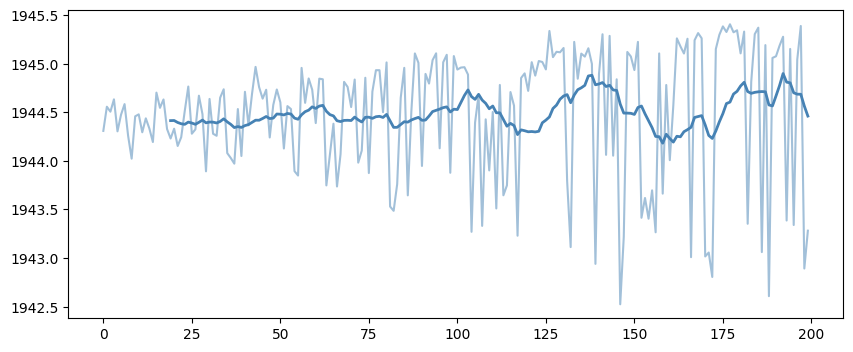

In [16]:
_ref = SAMPLE_CUSTOMERS[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(episode_costs, color="steelblue", alpha=0.5, label="Episode cost")
smoothed = pd.Series(episode_costs).rolling(20).mean()
ax.plot(smoothed, color="steelblue", linewidth=2, label="20-ep rolling mean")

ax.axhline(no_battery_results[_ref]["total_cost"],  color="red",    linestyle="--", label="No battery")
ax.axhline(self_cons_results[_ref]["total_cost"],   color="orange", linestyle="--", label="Self-consumption")
ax.axhline(off_peak_results[_ref]["total_cost"],    color="green",  linestyle="--", label="Off-peak charging")

ax.set_xlabel("Episode")
ax.set_ylabel(f"Total cost (A$) — customer {_ref}")
ax.set_title("Q-Learning Training Curve")
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
q_results = simulate_all(agent.greedy_policy(), "Q-Learning")


────────────────────────────────────────────────
Policy     : Q-Learning
Customer   : 63
Total cost      : A$1942.57
Saving vs grid  : A$2.84  (0.1%)
Avg battery SoC : 0.01 kWh


────────────────────────────────────────────────
Policy     : Q-Learning
Customer   : 48
Total cost      : A$1679.78
Saving vs grid  : A$167.25  (9.1%)
Avg battery SoC : 0.33 kWh


────────────────────────────────────────────────
Policy     : Q-Learning
Customer   : 191
Total cost      : A$1622.37
Saving vs grid  : A$209.41  (11.4%)
Avg battery SoC : 1.04 kWh


## 8. Comparing All Policies

In [13]:
all_results = {
    "No battery":       no_battery_results,
    "Self-consumption":  self_cons_results,
    "Off-peak":          off_peak_results,
    "Q-Learning":        q_results,
}

rows = []
for policy_name, policy_res in all_results.items():
    for cid, r in policy_res.items():
        rows.append({
            "Policy":            policy_name,
            "Customer":          cid,
            "Total cost (A$)":   round(r["total_cost"], 2),
            "Saving (A$)":       round(r["saving_vs_baseline"], 2),
            "Saving (%)": f"{r['saving_pct']:.1f}%",
        })

summary = pd.DataFrame(rows).set_index(["Policy", "Customer"])
summary


Total cost (A$)  Saving (A$) Saving (%)
Policy           Customer                                         
No battery       63                1945.40         0.00       0.0%
                 48                1847.02        -0.00      -0.0%
                 191               1831.78        -0.00      -0.0%
Self-consumption 63                1942.77         2.64       0.1%
                 48                1395.98       451.05      24.4%
                 191               1437.20       394.58      21.5%
Off-peak         63                1945.40         0.00       0.0%
                 48                1847.02        -0.00      -0.0%
                 191               1831.78        -0.00      -0.0%
Q-Learning       63                1942.57         2.84       0.1%
                 48                1679.78       167.25       9.1%
                 191               1622.37       209.41      11.4%

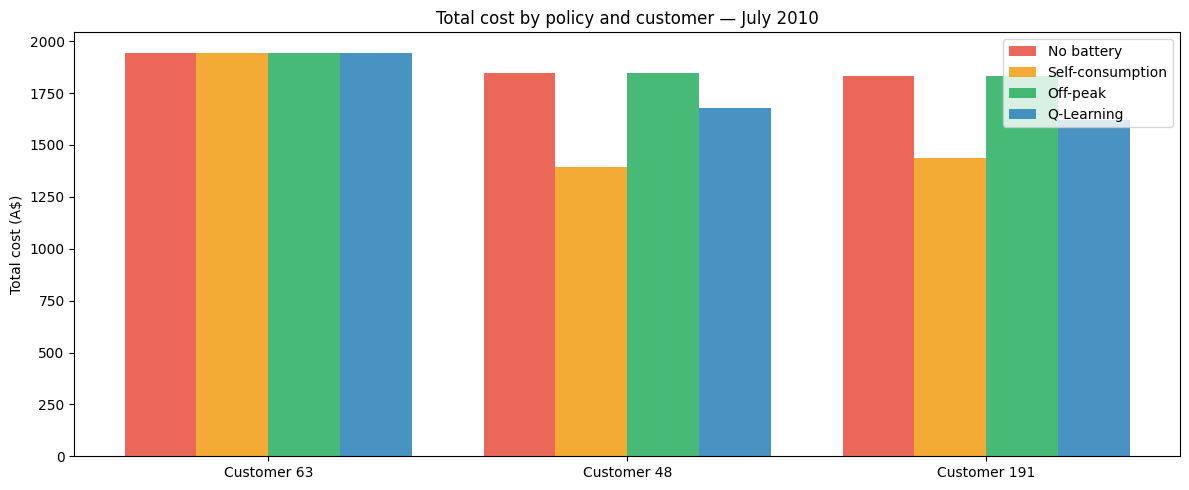

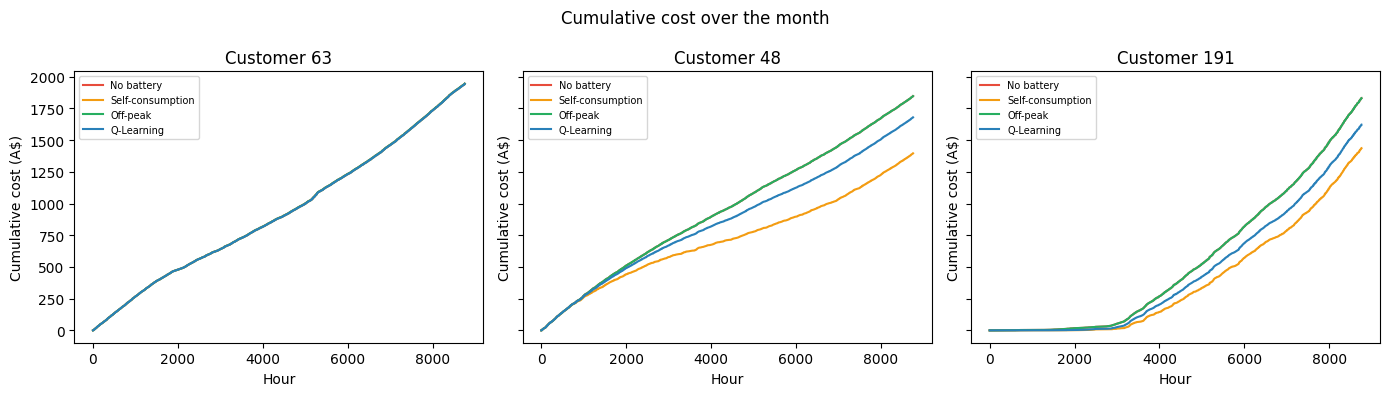

In [14]:
policy_names = list(all_results.keys())
cids         = SAMPLE_CUSTOMERS
x            = np.arange(len(cids))
width        = 0.8 / len(policy_names)
colours      = ["#e74c3c", "#f39c12", "#27ae60", "#2980b9"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (pname, colour) in enumerate(zip(policy_names, colours)):
    costs  = [all_results[pname][cid]["total_cost"] for cid in cids]
    offset = (i - len(policy_names) / 2 + 0.5) * width
    ax.bar(x + offset, costs, width, label=pname, color=colour, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f"Customer {cid}" for cid in cids])
ax.set_ylabel("Total cost (A$)")
ax.set_title("Total cost by policy and customer — July 2010")
ax.legend()
plt.tight_layout()
plt.show()

# Cumulative cost curves
fig, axes = plt.subplots(1, len(cids), figsize=(14, 4), sharey=True)
fig.suptitle("Cumulative cost over the month")
for ax, cid in zip(axes, cids):
    for pname, colour in zip(policy_names, colours):
        cum = np.cumsum(all_results[pname][cid]["costs"])
        ax.plot(cum, label=pname, color=colour)
    ax.set_title(f"Customer {cid}")
    ax.set_xlabel("Hour")
    ax.set_ylabel("Cumulative cost (A$)")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


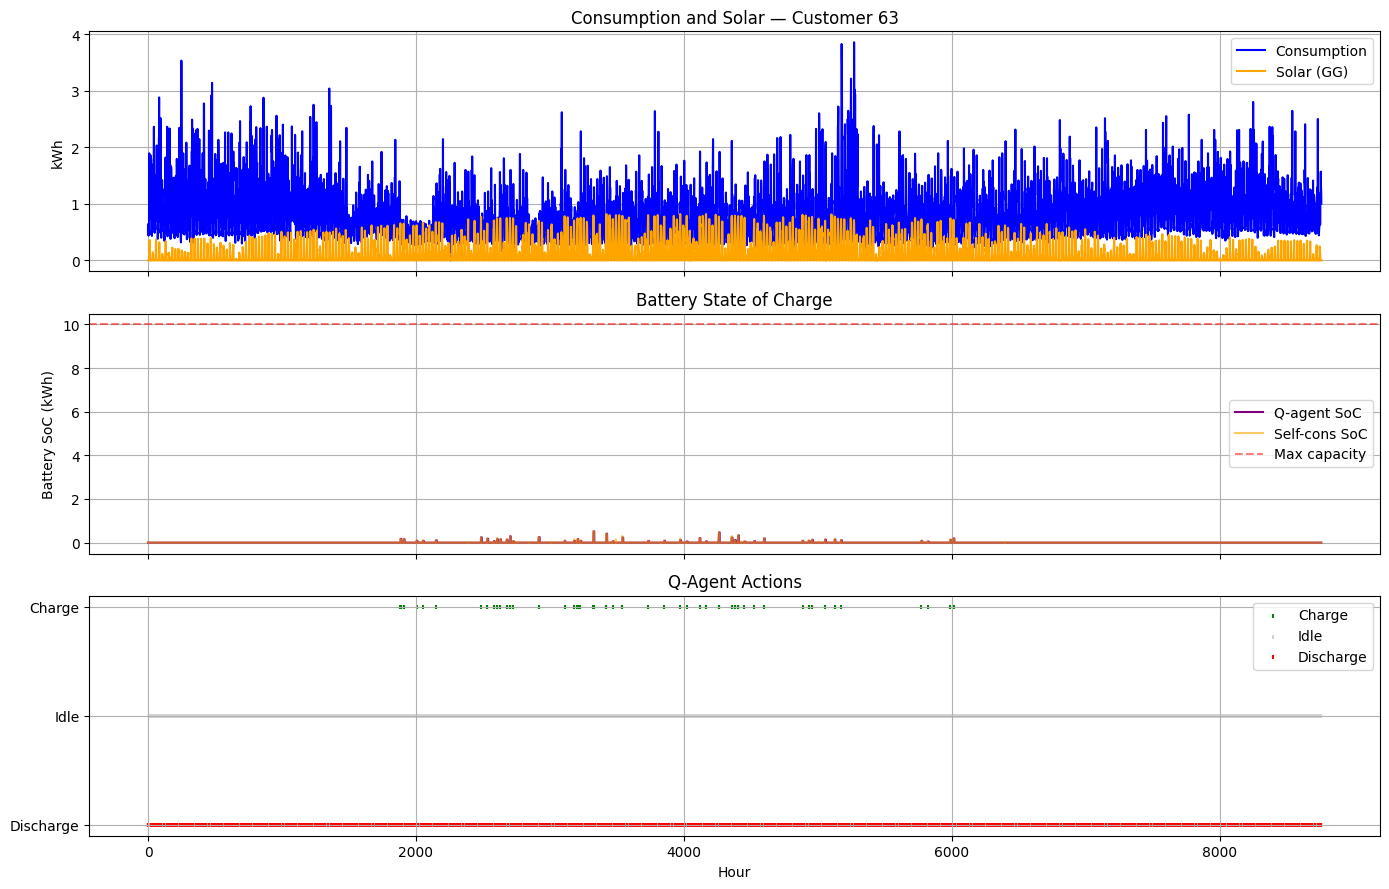

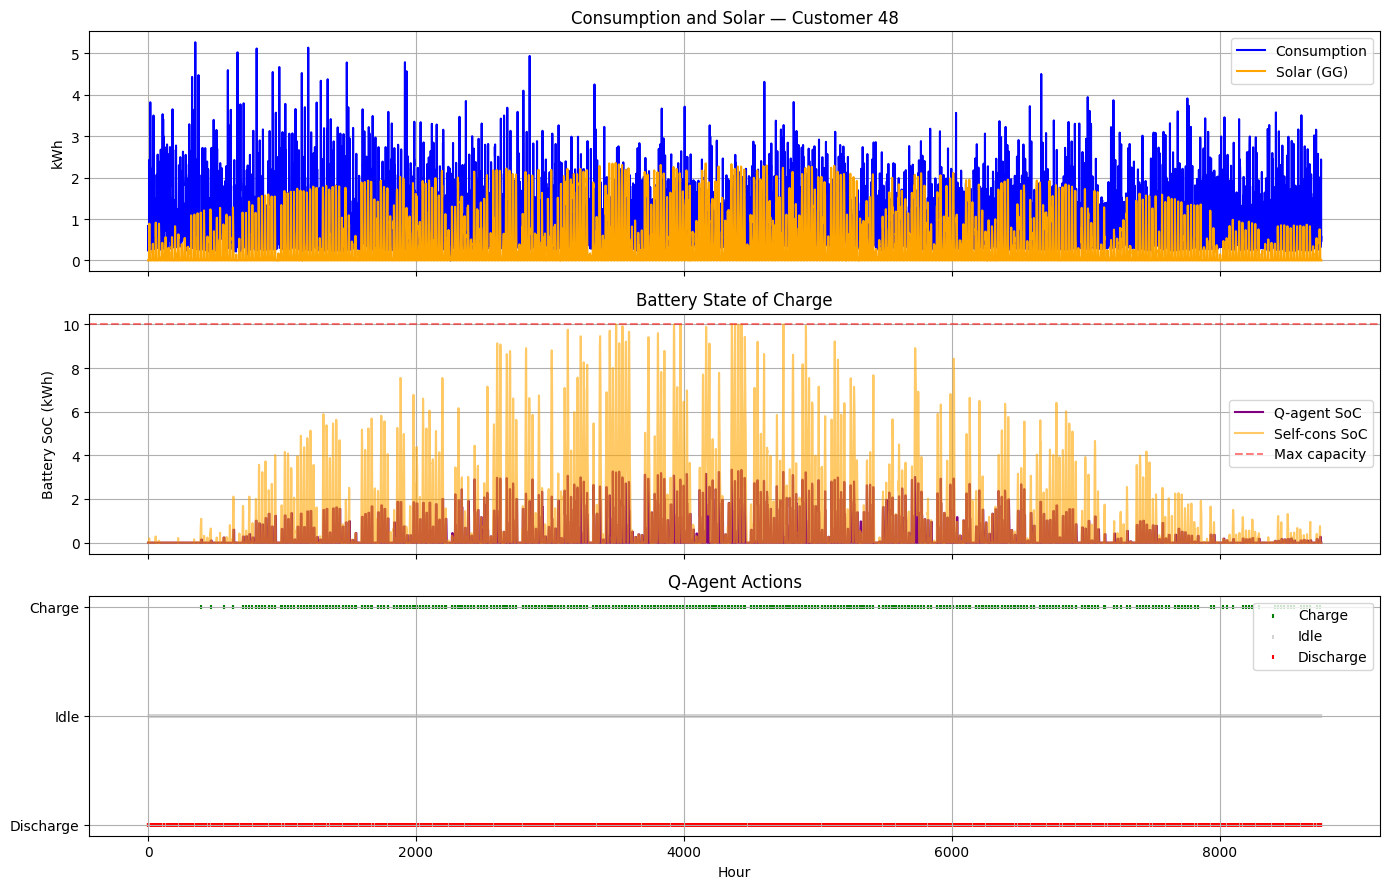

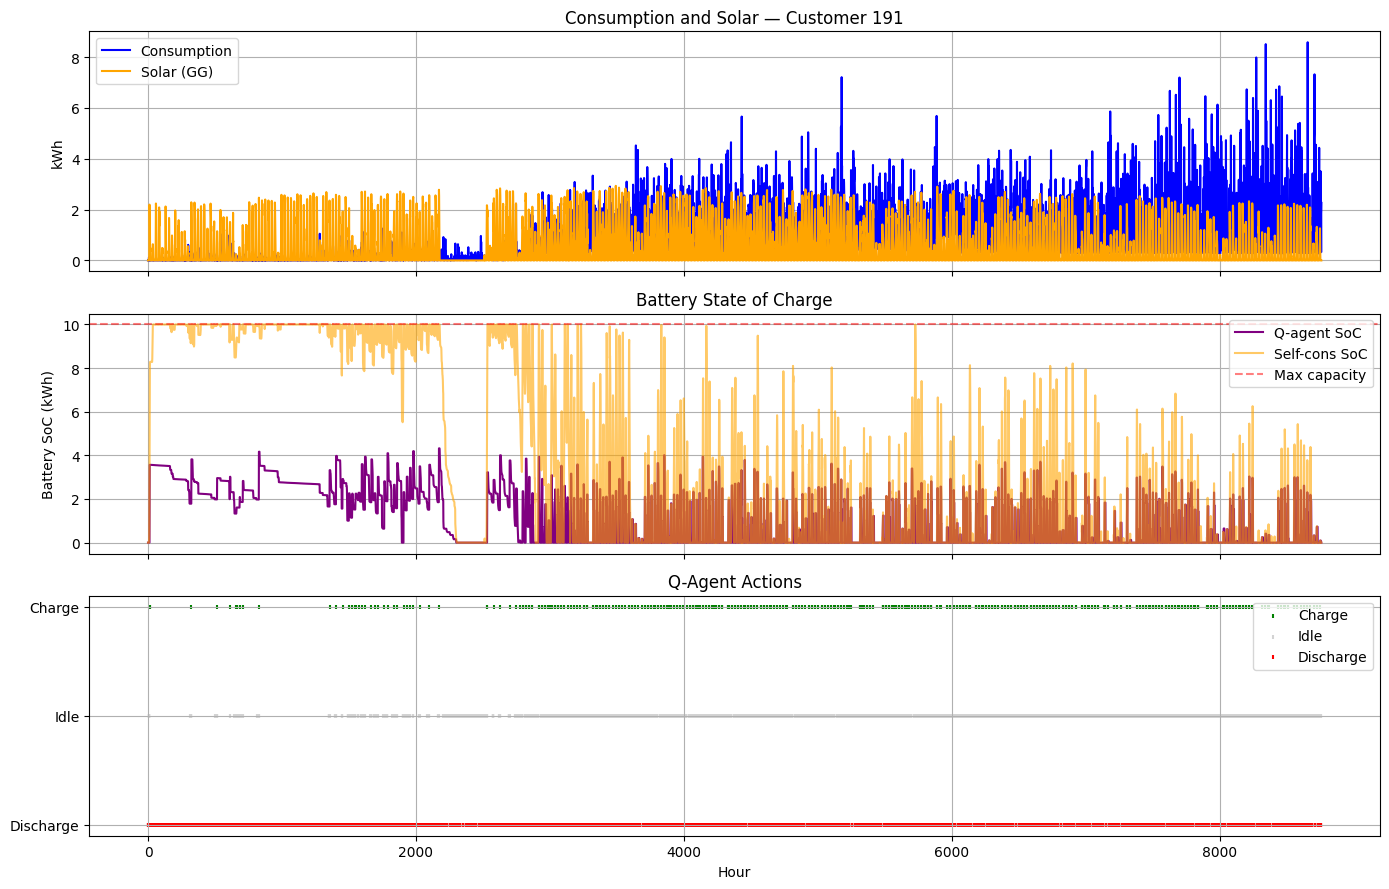

In [15]:
for cid in SAMPLE_CUSTOMERS:
    focus_df = CUSTOMERS[cid]
    q_focus  = q_results[cid]
    sc_focus = self_cons_results[cid]

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    for ax in axes:
        ax.grid(visible=True, which="both")
    hours = range(len(focus_df))

    axes[0].plot(hours, focus_df["total_consumption"].values, label="Consumption", color="blue")
    axes[0].plot(hours, focus_df["gg_kwh"].values,            label="Solar (GG)",  color="orange")
    axes[0].set_ylabel("kWh")
    axes[0].set_title(f"Consumption and Solar — Customer {cid}")
    axes[0].legend()

    axes[1].plot(hours, q_focus["soc_trace"],  color="purple", label="Q-agent SoC")
    axes[1].plot(hours, sc_focus["soc_trace"], color="orange", alpha=0.6, label="Self-cons SoC")
    axes[1].axhline(BATTERY_CAPACITY_KWH, color="red", linestyle="--", alpha=0.5, label="Max capacity")
    axes[1].set_ylabel("Battery SoC (kWh)")
    axes[1].set_title("Battery State of Charge")
    axes[1].legend()

    action_colours = {1: "green", 0: "lightgrey", -1: "red"}
    action_labels  = {1: "Charge", 0: "Idle",     -1: "Discharge"}
    for action in [1, 0, -1]:
        mask = np.array(q_focus["actions"]) == action
        axes[2].scatter(
            np.where(mask)[0], [action] * mask.sum(),
            c=action_colours[action], label=action_labels[action], s=8, marker="|"
        )
    axes[2].set_yticks([-1, 0, 1])
    axes[2].set_yticklabels(["Discharge", "Idle", "Charge"])
    axes[2].set_xlabel("Hour")
    axes[2].set_title("Q-Agent Actions")
    axes[2].legend(loc="upper right")

    plt.tight_layout()
    plt.show()


## 9. Reflection and Next Steps

### What Q-learning can and can't do here

With a **120-state Q-table** and one month of data, Q-learning has limited resolution.
The discretisation loses information — for example, it can't distinguish between
SoC=2.1 kWh and SoC=3.8 kWh (both bin to the same state).

This is the core motivation for **Deep Q-Networks (DQN)**: instead of a lookup table,
use a neural network to approximate Q(s, a) — giving the agent the ability to generalise
across similar states with arbitrary precision.

### Things to experiment with before Phase 2

Try changing these values and re-running the notebook to build intuition:

- `alpha` (learning rate): what happens at 0.5? At 0.001?
- `gamma` (discount): lower values (0.7) make the agent more short-sighted — does it still learn to charge off-peak?
- `epsilon_decay_episodes`: what if exploration decays very quickly (10 episodes)?
- State bins: what if you add more SoC bins (10 instead of 5)?
- `n_episodes`: does the agent plateau or keep improving?

### Phase 2: Gymnasium environment

The next step is to wrap this problem in a proper `gymnasium.Env`. This will:
- Provide a standard `reset()` / `step()` interface compatible with all major RL libraries
- Enable random episode starts (more training variance, better generalisation)
- Support a **continuous observation space** (no discretisation needed for DQN)
- Allow plugging in Stable-Baselines3 or other RL frameworks for comparison